In [177]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

In [178]:
df = pd.read_csv("data/laptop_prices.csv")

In [179]:
df.head()

,Company,Product,TypeName,Inches,Ram,OS,Weight,Price_euros,Screen,ScreenW,...,RetinaDisplay,CPU_company,CPU_freq,CPU_model,PrimaryStorage,SecondaryStorage,PrimaryStorageType,SecondaryStorageType,GPU_company,GPU_model
0,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1339.69,Standard,2560,...,Yes,Intel,2.3,Core i5,128,0,SSD,No,Intel,Iris Plus Graphics 640
1,Apple,Macbook Air,Ultrabook,13.3,8,macOS,1.34,898.94,Standard,1440,...,No,Intel,1.8,Core i5,128,0,Flash Storage,No,Intel,HD Graphics 6000
2,HP,250 G6,Notebook,15.6,8,No OS,1.86,575.00,Full HD,1920,...,No,Intel,2.5,Core i5 7200U,256,0,SSD,No,Intel,HD Graphics 620
3,Apple,MacBook Pro,Ultrabook,15.4,16,macOS,1.83,2537.45,Standard,2880,...,Yes,Intel,2.7,Core i7,512,0,SSD,No,AMD,Radeon Pro 455
4,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1803.60,Standard,2560,...,Yes,Intel,3.1,Core i5,256,0,SSD,No,Intel,Iris Plus Graphics 650


In [180]:
df.shape

(1275, 23)

In [181]:
df.columns

Index(['Company', 'Product', 'TypeName', 'Inches', 'Ram', 'OS', 'Weight',
       'Price_euros', 'Screen', 'ScreenW', 'ScreenH', 'Touchscreen',
       'IPSpanel', 'RetinaDisplay', 'CPU_company', 'CPU_freq', 'CPU_model',
       'PrimaryStorage', 'SecondaryStorage', 'PrimaryStorageType',
       'SecondaryStorageType', 'GPU_company', 'GPU_model'],
      dtype='str')

In [182]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Company               1275 non-null   str    
 1   Product               1275 non-null   str    
 2   TypeName              1275 non-null   str    
 3   Inches                1275 non-null   float64
 4   Ram                   1275 non-null   int64  
 5   OS                    1275 non-null   str    
 6   Weight                1275 non-null   float64
 7   Price_euros           1275 non-null   float64
 8   Screen                1275 non-null   str    
 9   ScreenW               1275 non-null   int64  
 10  ScreenH               1275 non-null   int64  
 11  Touchscreen           1275 non-null   str    
 12  IPSpanel              1275 non-null   str    
 13  RetinaDisplay         1275 non-null   str    
 14  CPU_company           1275 non-null   str    
 15  CPU_freq              1275 non-n

In [183]:
df.describe()

,Inches,Ram,Weight,Price_euros,ScreenW,ScreenH,CPU_freq,PrimaryStorage,SecondaryStorage
count,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000
mean,15.022902,8.440784,2.040525,1134.969059,1900.043922,1073.904314,2.302980,444.517647,176.069020
std,1.429470,5.097809,0.669196,700.752504,493.346186,283.883940,0.503846,365.537726,415.960655
min,10.100000,2.000000,0.690000,174.000000,1366.000000,768.000000,0.900000,8.000000,0.000000
25%,14.000000,4.000000,1.500000,609.000000,1920.000000,1080.000000,2.000000,256.000000,0.000000
50%,15.600000,8.000000,2.040000,989.000000,1920.000000,1080.000000,2.500000,256.000000,0.000000
75%,15.600000,8.000000,2.310000,1496.500000,1920.000000,1080.000000,2.700000,512.000000,0.000000
max,18.400000,64.000000,4.700000,6099.000000,3840.000000,2160.000000,3.600000,2048.000000,2048.000000


In [184]:
df.isnull().sum()

Company                 0
Product                 0
TypeName                0
Inches                  0
Ram                     0
OS                      0
Weight                  0
Price_euros             0
Screen                  0
ScreenW                 0
ScreenH                 0
Touchscreen             0
IPSpanel                0
RetinaDisplay           0
CPU_company             0
CPU_freq                0
CPU_model               0
PrimaryStorage          0
SecondaryStorage        0
PrimaryStorageType      0
SecondaryStorageType    0
GPU_company             0
GPU_model               0
dtype: int64

In [185]:
df.duplicated().sum()

np.int64(0)

In [186]:
df.dtypes

Company                     str
Product                     str
TypeName                    str
Inches                  float64
Ram                       int64
OS                          str
Weight                  float64
Price_euros             float64
Screen                      str
ScreenW                   int64
ScreenH                   int64
Touchscreen                 str
IPSpanel                    str
RetinaDisplay               str
CPU_company                 str
CPU_freq                float64
CPU_model                   str
PrimaryStorage            int64
SecondaryStorage          int64
PrimaryStorageType          str
SecondaryStorageType        str
GPU_company                 str
GPU_model                   str
dtype: object

In [187]:
df.columns

Index(['Company', 'Product', 'TypeName', 'Inches', 'Ram', 'OS', 'Weight',
       'Price_euros', 'Screen', 'ScreenW', 'ScreenH', 'Touchscreen',
       'IPSpanel', 'RetinaDisplay', 'CPU_company', 'CPU_freq', 'CPU_model',
       'PrimaryStorage', 'SecondaryStorage', 'PrimaryStorageType',
       'SecondaryStorageType', 'GPU_company', 'GPU_model'],
      dtype='str')

In [188]:
df.rename(columns={"Price_euros": "Price"}, inplace=True)


In [189]:
df["Price"]

0       1339.69
1        898.94
2        575.00
3       2537.45
4       1803.60
         ...   
1270     638.00
1271    1499.00
1272     229.00
1273     764.00
1274     369.00
Name: Price, Length: 1275, dtype: float64

<Axes: xlabel='Price', ylabel='Count'>

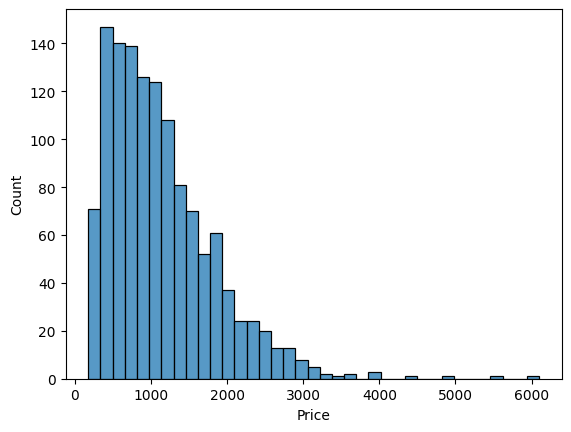

In [190]:
sns.histplot(df["Price"])

In [191]:
plt.show()

In [192]:
df.corr(numeric_only=True)

,Inches,Ram,Weight,Price,ScreenW,ScreenH,CPU_freq,PrimaryStorage,SecondaryStorage
Inches,1.000000,0.241078,0.826638,0.066608,-0.068223,-0.093062,0.305037,0.264280,0.389067
Ram,0.241078,1.000000,0.389370,0.740287,0.424089,0.415241,0.366254,0.015365,0.390939
Weight,0.826638,0.389370,1.000000,0.211883,-0.028605,-0.050106,0.318649,0.175433,0.481495
Price,0.066608,0.740287,0.211883,1.000000,0.552491,0.548529,0.428847,-0.124775,0.291207
ScreenW,-0.068223,0.424089,-0.028605,0.552491,1.000000,0.994069,0.178659,-0.072977,0.146232
ScreenH,-0.093062,0.415241,-0.050106,0.548529,0.994069,1.000000,0.164369,-0.080135,0.135293
CPU_freq,0.305037,0.366254,0.318649,0.428847,0.178659,0.164369,1.000000,0.056320,0.224521
PrimaryStorage,0.264280,0.015365,0.175433,-0.124775,-0.072977,-0.080135,0.056320,1.000000,-0.244182
SecondaryStorage,0.389067,0.390939,0.481495,0.291207,0.146232,0.135293,0.224521,-0.244182,1.000000


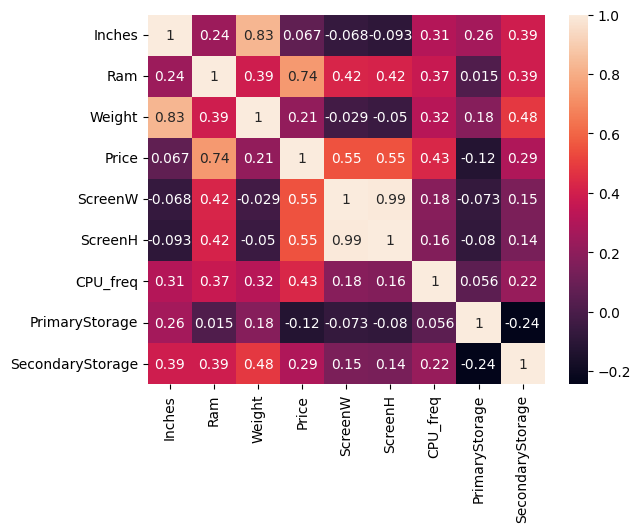

In [193]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [194]:
selected_features = [
    "Company",
    "TypeName",
    "Ram",
    "PrimaryStorage",
    "CPU_company",
    "CPU_freq",
    "Inches",
    "OS"
]

X = df[selected_features]
y = df["Price"]

In [195]:
print(X)
y

     Company            TypeName  Ram  PrimaryStorage CPU_company  CPU_freq  \
0      Apple           Ultrabook    8             128       Intel       2.3   
1      Apple           Ultrabook    8             128       Intel       1.8   
2         HP            Notebook    8             256       Intel       2.5   
3      Apple           Ultrabook   16             512       Intel       2.7   
4      Apple           Ultrabook    8             256       Intel       3.1   
...      ...                 ...  ...             ...         ...       ...   
1270  Lenovo  2 in 1 Convertible    4             128       Intel       2.5   
1271  Lenovo  2 in 1 Convertible   16             512       Intel       2.5   
1272  Lenovo            Notebook    2              64       Intel       1.6   
1273      HP            Notebook    6            1024       Intel       2.5   
1274    Asus            Notebook    4             500       Intel       1.6   

      Inches          OS  
0       13.3       macOS

0       1339.69
1        898.94
2        575.00
3       2537.45
4       1803.60
         ...   
1270     638.00
1271    1499.00
1272     229.00
1273     764.00
1274     369.00
Name: Price, Length: 1275, dtype: float64

In [196]:
X.dtypes

Company               str
TypeName              str
Ram                 int64
PrimaryStorage      int64
CPU_company           str
CPU_freq          float64
Inches            float64
OS                    str
dtype: object

In [197]:
categorical_columns = X.select_dtypes(include="object").columns

numerical_columns = X.select_dtypes(exclude="object").columns

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_31652\1219225164.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include="object").columns


In [198]:
categorical_columns

Index(['Company', 'TypeName', 'CPU_company', 'OS'], dtype='str')

In [199]:
numerical_columns

Index(['Ram', 'PrimaryStorage', 'CPU_freq', 'Inches'], dtype='str')

In [200]:
preprocessor = ColumnTransformer(
    transformers=[
        ("encoder", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ],
    remainder="passthrough"
)

In [201]:
model = LinearRegression()

In [202]:
print(model)

LinearRegression()


In [203]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

In [204]:
print(pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Company', 'TypeName', 'CPU_company', 'OS'], dtype='str'))])),
                ('model', LinearRegression())])


In [205]:
y_log = np.log(y)

In [206]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_log,
    test_size=0.2,
    random_state=0
)

In [207]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('encoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers conta

In [208]:
y_pred = pipeline.predict(X_test)

In [209]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head()

,Actual,Predicted
699,6.535241,6.707506
649,7.367709,7.303126
310,6.906755,6.793230
186,7.781973,7.318502
184,7.089243,6.327182


In [210]:
r2 = r2_score(y_test, y_pred)
print(r2)
mae = mean_absolute_error(y_test, y_pred)
print(mae)

0.7793161613727984
0.22281808364506375


In [211]:
print(y.min())
print(y.max())
print(y.mean())

174.0
6099.0
1134.9690588235292


In [212]:
y.describe()

count    1275.000000
mean     1134.969059
std       700.752504
min       174.000000
25%       609.000000
50%       989.000000
75%      1496.500000
max      6099.000000
Name: Price, dtype: float64

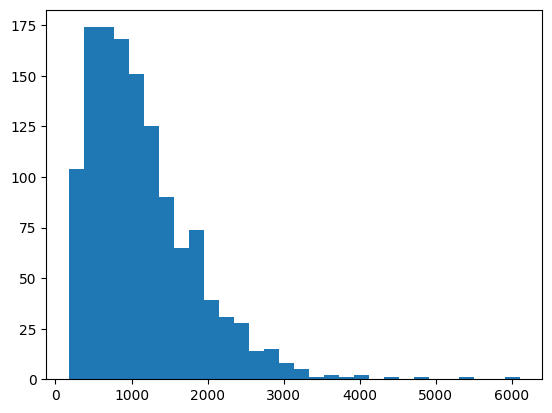

In [213]:
plt.hist(y, bins=30)
plt.show()

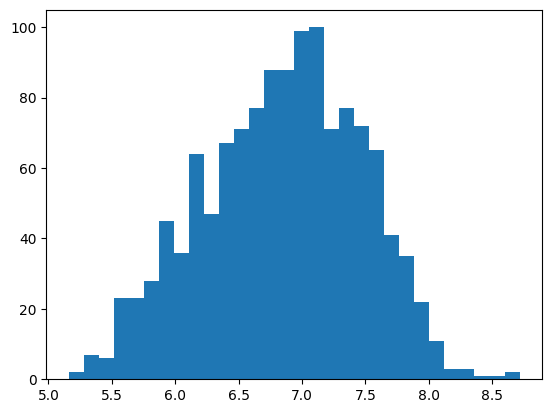

In [214]:
plt.hist(y_log, bins=30)
plt.show()

In [215]:
y_pred_price = np.exp(y_pred)
y_test_price = np.exp(y_test)

In [216]:
mae_price = mean_absolute_error(
    y_test_price,
    y_pred_price
)

print(mae_price)

273.83308872624593


In [217]:
comparison = pd.DataFrame({
    "Actual": y_test_price,
    "Predicted": y_pred_price
})

print(comparison.head(10))

     Actual    Predicted
699   689.0   818.526456
649  1584.0  1484.934997
310   999.0   891.789446
186  2397.0  1507.942975
184  1199.0   559.577513
55    767.8   761.859276
871   479.0   396.936673
741   665.0   810.765584
364   499.0   557.457952
422  1427.0  1118.112713


In [218]:
import pickle

pickle.dump(pipeline, open("pipe.pkl", "wb"))

In [219]:
print(X.columns.tolist())


['Company', 'TypeName', 'Ram', 'PrimaryStorage', 'CPU_company', 'CPU_freq', 'Inches', 'OS']


In [220]:
actual_price = np.exp(y_test.iloc[0])

predicted_price = np.exp(
    pipeline.predict(X_test.iloc[[0]])
)[0]

print("Actual:", actual_price)
print("Predicted:", predicted_price)

Actual: 689.0000000000001
Predicted: 818.5264564975993


In [221]:
import pickle

model = pickle.load(open("pipe.pkl", "rb"))

In [222]:

print(type(pipeline))

<class 'sklearn.pipeline.Pipeline'>


In [223]:
y_pred_log = pipeline.predict(X_test)

comparison = pd.DataFrame({
    "Actual Price": np.exp(y_test),
    "Predicted Price": np.exp(y_pred_log)
})

print(comparison.head(10))

     Actual Price  Predicted Price
699         689.0       818.526456
649        1584.0      1484.934997
310         999.0       891.789446
186        2397.0      1507.942975
184        1199.0       559.577513
55          767.8       761.859276
871         479.0       396.936673
741         665.0       810.765584
364         499.0       557.457952
422        1427.0      1118.112713


In [224]:
y_pred_log = pipeline.predict(X_test)

In [225]:
comparison = pd.DataFrame({
    "Actual": np.exp(y_test),
    "Predicted": np.exp(y_pred_log)
})

comparison["Error"] = abs(
    comparison["Actual"] - comparison["Predicted"]
)

comparison.head(10)

,Actual,Predicted,Error
699,689.0,818.526456,129.526456
649,1584.0,1484.934997,99.065003
310,999.0,891.789446,107.210554
186,2397.0,1507.942975,889.057025
184,1199.0,559.577513,639.422487
55,767.8,761.859276,5.940724
871,479.0,396.936673,82.063327
741,665.0,810.765584,145.765584
364,499.0,557.457952,58.457952
422,1427.0,1118.112713,308.887287


In [226]:
comparison.sort_values(
    "Error",
    ascending=False
).head(10)

,Actual,Predicted,Error
491,2799.00,5903.016444,3104.016444
1231,3499.00,1900.269419,1598.730581
610,4899.00,3314.338894,1584.661106
247,2999.00,1758.882959,1240.117041
693,2590.00,1406.969676,1183.030324
494,1269.00,2427.703271,1158.703271
1017,2968.00,1853.276395,1114.723605
904,1962.99,863.040019,1099.949981
464,2090.00,1021.301747,1068.698253
744,3299.00,2280.809467,1018.190533


In [227]:
X_test.loc[610]

Company               Lenovo
TypeName            Notebook
Ram                       32
PrimaryStorage          1024
CPU_company            Intel
CPU_freq                 3.1
Inches                  15.6
OS                Windows 10
Name: 610, dtype: object

In [228]:
df[df["CPU_model"].str.contains("Xeon", na=False)].shape

(4, 23)

In [229]:
df[df["GPU_model"].str.contains("Quadro", na=False)].shape

(31, 23)

In [230]:
comparison["Percentage_Error"] = (
    comparison["Error"] / comparison["Actual"]
) * 100

comparison.sort_values(
    "Percentage_Error",
    ascending=False
).head(10)

,Actual,Predicted,Error,Percentage_Error
1268,209.0,579.829001,370.829001,177.430144
1133,752.0,1650.352797,898.352797,119.461808
491,2799.0,5903.016444,3104.016444,110.897336
494,1269.0,2427.703271,1158.703271,91.308374
395,499.0,940.786134,441.786134,88.534295
159,447.0,761.101925,314.101925,70.268887
156,629.0,1041.140111,412.140111,65.523070
1072,1199.0,1895.884297,696.884297,58.122127
953,1159.0,494.006460,664.993540,57.376492
825,499.0,780.345233,281.345233,56.381810


In [231]:
X_test.loc[1268]

Company                   HP
TypeName             Netbook
Ram                        2
PrimaryStorage            32
CPU_company            Intel
CPU_freq                 1.6
Inches                  11.6
OS                Windows 10
Name: 1268, dtype: object

In [232]:
df.to_csv("cleaned_laptop.csv", index=False)

In [233]:
import os

print(os.path.getsize("pipe.pkl"))

3186
